In [4]:
import os

input_folder = "Original_Images"

print("Total Images:", len(os.listdir(input_folder)))

Total Images: 800


In [5]:
from PIL import Image
import os

bad = []

for file in os.listdir("Original_Images"):
    if file.lower().endswith(".png"):
        try:
            img = Image.open(os.path.join("Original_Images", file))
            img.verify()
        except Exception:
            bad.append(file)

print("Corrupted Images:", len(bad))

Corrupted Images: 0


In [6]:
import os
import cv2

# ==========================================
# Folder Paths
# ==========================================

input_folder = "Original_Images"
output_folder = "Resized_Images"

# ==========================================
# Resize Dimensions
# ==========================================

width = 224
height = 224

# ==========================================
# Get all image names
# ==========================================

image_files = [
    file for file in os.listdir(input_folder)
    if file.lower().endswith(".png")
]

print("Total Images Found:", len(image_files))

# Counter
count = 0

# ==========================================
# Resize Images One by One
# ==========================================

for image_name in image_files:

    # Input image path
    input_path = os.path.join(input_folder, image_name)

    # Output image path
    output_path = os.path.join(output_folder, image_name)

    # Read image
    image = cv2.imread(input_path)

    # Skip if image cannot be read
    if image is None:
        print(f"Could not read: {image_name}")
        continue

    # Resize image
    resized_image = cv2.resize(
        image,
        (width, height),
        interpolation=cv2.INTER_LINEAR
    )

    # Save resized image
    cv2.imwrite(output_path, resized_image)

    count += 1

print("\n===================================")
print("Resizing Completed Successfully!")
print("Total Images Resized:", count)
print("Saved in Folder:", output_folder)
print("===================================")

Total Images Found: 800

Resizing Completed Successfully!
Total Images Resized: 800
Saved in Folder: Resized_Images


Image Shape: (224, 224, 3)


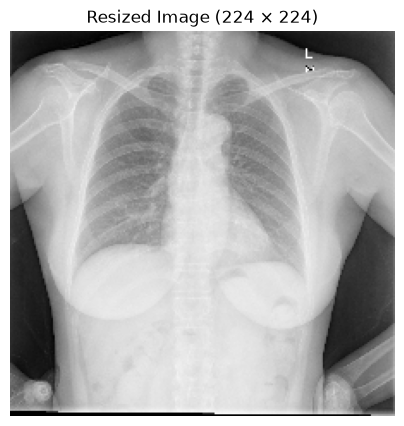

In [8]:
import cv2
import matplotlib.pyplot as plt

# Read one resized image
image = cv2.imread("Resized_Images/CHNCXR_0040_0.png")

# Convert BGR to RGB for display
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image Shape:", image.shape)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title("Resized Image (224 × 224)")
plt.axis("off")
plt.show()

In [9]:
import cv2

image = cv2.imread("Resized_Images/CHNCXR_0001_0.png")

print(image.shape)

(224, 224, 3)


In [10]:
import os
import cv2

# ==========================================
# Folder Paths
# ==========================================

input_folder = "Resized_Images"
output_folder = "CLAHE_Images"

# ==========================================
# Create CLAHE Object
# ==========================================

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

# ==========================================
# Read Image Names
# ==========================================

image_files = [
    file for file in os.listdir(input_folder)
    if file.lower().endswith(".png")
]

print("Total Images Found:", len(image_files))

count = 0

# ==========================================
# Apply CLAHE
# ==========================================

for image_name in image_files:

    input_path = os.path.join(input_folder, image_name)
    output_path = os.path.join(output_folder, image_name)

    # Read image in grayscale
    image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print("Cannot Read:", image_name)
        continue

    # Apply CLAHE
    clahe_image = clahe.apply(image)

    # Save Image
    cv2.imwrite(output_path, clahe_image)

    count += 1

print("\n===================================")
print("CLAHE Completed Successfully")
print("Images Processed :", count)
print("Saved Inside :", output_folder)
print("===================================")

Total Images Found: 800

CLAHE Completed Successfully
Images Processed : 800
Saved Inside : CLAHE_Images


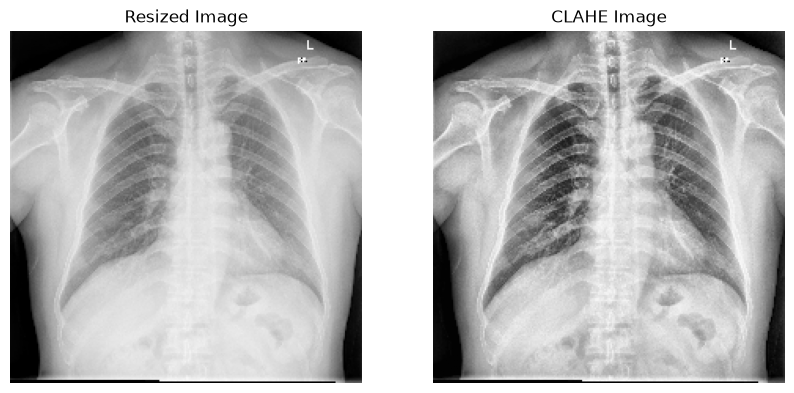

In [11]:
import cv2
import matplotlib.pyplot as plt

# Read Original Resized Image
original = cv2.imread(
    "Resized_Images/CHNCXR_0001_0.png",
    cv2.IMREAD_GRAYSCALE
)

# Read CLAHE Image
clahe = cv2.imread(
    "CLAHE_Images/CHNCXR_0001_0.png",
    cv2.IMREAD_GRAYSCALE
)

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original, cmap="gray")
plt.title("Resized Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(clahe, cmap="gray")
plt.title("CLAHE Image")
plt.axis("off")

plt.show()